In [63]:
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

---
## 데이터 세팅 (reverse.ipynb & reverse_test_init_dist.ipynb 동일)

In [64]:
rng = np.random.default_rng(42)

# ── Heart dataset ─────────────────────────────────────────────────────────────
heart_t = np.linspace(0, 2 * np.pi, 20, endpoint=False)
heart_means = np.column_stack([
    16 * np.sin(heart_t) ** 3,
    13 * np.cos(heart_t) - 5 * np.cos(2 * heart_t)
    - 2 * np.cos(3 * heart_t) - np.cos(4 * heart_t),
]) / 10  # (20, 2)

heart_std = 0.07
heart_x0 = np.vstack([
    mu + rng.standard_normal((80, 2)) * heart_std for mu in heart_means
])  # (1600, 2)

# ── Noise schedule ────────────────────────────────────────────────────────────
T = 500

def beta_fn(t):
    t = np.clip(t, 0, T - 1)
    return 1e-4 + (0.02 - 1e-4) * t / (T - 1)

def alpha_bar_fn(t):
    t = np.clip(t, 0, T - 1)
    a = 1e-4; b = (0.02 - 1e-4) / (T - 1)
    return np.exp(-(a * t + 0.5 * b * t**2))

def sigma2_fn(t):
    return 1.0 - alpha_bar_fn(t)

# ── GMM exact score ───────────────────────────────────────────────────────────
def gmm_score(x, t, means=heart_means, var=heart_std**2):
    ab    = alpha_bar_fn(t)
    s2    = sigma2_fn(t)
    mu_t  = np.sqrt(ab) * means
    var_t = ab * var + s2
    diff  = x[:, None, :] - mu_t[None, :, :]
    log_pk = -(diff**2).sum(-1) / (2 * var_t)
    log_pk -= log_pk.max(1, keepdims=True)
    wk = np.exp(log_pk); wk /= wk.sum(1, keepdims=True)
    return (wk[:, :, None] * (-diff / var_t)).sum(1)

heart_score = partial(gmm_score, means=heart_means, var=heart_std**2)

# ── Forward SDE ───────────────────────────────────────────────────────────────
def forward_sde(x0):
    saved = {0: x0.copy()}
    x = x0.copy()
    for i in range(T):
        b = beta_fn(i)
        x = x * (1 - 0.5 * b) + np.sqrt(b) * rng.standard_normal(x.shape)
        saved[i + 1] = x.copy()
    return saved

heart_forward = forward_sde(heart_x0)

# ── Euler-Maruyama reverse (matches reverse_test_init_dist.ipynb exactly) ─────
# Reverse SDE: dx = [-β/2·x - β·s] dt + sqrt(β) dW  (dt < 0 going T→0)
def reverse_em(x_T, score_fn):
    x = x_T.copy()
    dt = -1  # stepping backwards: t decreases by 1 each step
    for t in range(T, 0, -1):
        b = beta_fn(t)
        s = score_fn(x, t)
        x = x + b * (-0.5 * x - s) * dt + np.sqrt(b) * rng.standard_normal(x.shape)
    return x

# ── Initial distributions ─────────────────────────────────────────────────────
N = len(heart_x0)
initials = {
    "heart_forward_xT":      heart_forward[T].copy(),
    "normal_var_0.5":        rng.normal(0.0, np.sqrt(0.5), (N, 2)),
    "wide_normal_var_5":     rng.normal(0.0, np.sqrt(5.0), (N, 2)),
    "shifted_normal_mean_3": rng.normal(3.0, 1.0, (N, 2)),
    "uniform_square":        rng.uniform(-3.0, 3.0, (N, 2)),
    "extreme_offset":        rng.normal(5.0, 3.0, (N, 2)),
}

restored = {name: reverse_em(x_T, heart_score) for name, x_T in initials.items()}
print("Done. keys:", list(restored.keys()))

Done. keys: ['heart_forward_xT', 'normal_var_0.5', 'wide_normal_var_5', 'shifted_normal_mean_3', 'uniform_square', 'extreme_offset']


# 복원 품질 지표: MMD² & Mode Entropy

복원된 샘플 $\hat{x}_0$과 원본 데이터 $x_0$을 비교

---

## 1. MMD² — 분포 기준



### 개념

커널 특징 공간에서 두 분포의 차이를 측정 — 1-대-1 매칭 불필요.
위치 오프셋, 형태 왜곡 등 분포 전체의 불일치를 하나의 스칼라로 표현.

### 공식

$$
\text{MMD}^2(P, Q) = \mathbb{E}_{x,x' \sim P}[k(x,x')] - 2\,\mathbb{E}_{x \sim P,\, y \sim Q}[k(x,y)] + \mathbb{E}_{y,y' \sim Q}[k(y,y')]
$$

비편향 샘플 추정:

$$
\widehat{\text{MMD}}^2 = \frac{1}{N(N-1)}\sum_{i \neq j} k(x_i, x_j)
\;-\; \frac{2}{NM}\sum_{i,j} k(x_i, y_j)
\;+\; \frac{1}{M(M-1)}\sum_{i \neq j} k(y_i, y_j)
$$

### 커널 — Multi-scale RBF

$$
k(x, y) = \sum_{l} \exp\!\left(-\frac{\|x-y\|^2}{2\sigma_l^2}\right)
$$

- $x$끼리의 유사도 → $x$ 분포가 얼마나 뭉쳐있는가
- $y$끼리의 유사도 → $y$ 분포가 얼마나 뭉쳐있는가
- $x-y$ 교차 유사도 → 두 분포가 얼마나 겹치는가 

두 분포가 같다면 "$x$끼리 뭉친 정도" 와 "$x-y$가 겹치는 정도" 가 같아야 하므로 상쇄되어 0  
두 분포가 완전히 분리되어 있으면 x끼리는 가깝고 x-y는 멀어서 교차항이 작아지고 MMD²가 커짐  

단일 $\sigma$는 포화(saturation) 문제:
- 너무 작음 → 거리가 조금만 멀어도 $K_{xy} \approx 0$ → 모든 케이스가 최대치
- 너무 큼 → 세 항이 모두 비슷 → 모든 케이스가 0에 가까움

$[\sigma/4,\, \sigma/2,\, \sigma,\, 2\sigma,\, 4\sigma]$ 5개 스케일을 합산해 포화 없이 위치 차이와 형태 차이를 동시에 포착.
$\sigma$는 $x$와 $y$를 합친 pairwise 거리의 median heuristic으로 자동 결정.

---

In [65]:
def pairwise_sq_euclidean(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """유클리드 거리의 제곱값: ||a[i] - b[j]||² for all (i, j) 
    Shape: (len(a), len(b))"""
    # ||a - b||² = ||a||² + ||b||² - 2 a·b^T
    sq_a = (a ** 2).sum(axis=1, keepdims=True)   # (N, 1)
    sq_b = (b ** 2).sum(axis=1, keepdims=True).T  # (1, M)
    return sq_a + sq_b - 2 * (a @ b.T)


def pairwise_euclidean(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """유클리드 거리: ||a[i] - b[j]|| for all (i, j) 
    Shape: (len(a), len(b))"""
    return np.sqrt(pairwise_sq_euclidean(a, b))


def mmd_squared(x: np.ndarray, y: np.ndarray, sigmas=None) -> float:
    """
    x: 실제 데이터(정답), y: 모델이 생성한 샘플
    Unbiased MMD² with multi-scale RBF kernel: k(x,y) = sum_l exp(-||x-y||²/2σ_l²)
    sigmas: None → [σ/4, σ/2, σ, 2σ, 4σ] where σ = median heuristic on pooled x, y
    """
    if sigmas is None:
        xy = np.vstack([x, y])
        pairwise = pairwise_euclidean(xy, xy)  # 대각성분(자기 자신) 값=0, 대칭행렬
        # 대각성분 위 원소들의 인덱스(상삼각 부분): (i,j)거리 = (j,i)거리
        idx = np.triu_indices(len(xy), k=1)    
        base = float(np.median(pairwise[idx])) # 데이터들 사이의 거리 중간값 
        sigmas = [base / 4, base / 2, base, base * 2, base * 4]

    sq_xx = pairwise_sq_euclidean(x, x)
    sq_yy = pairwise_sq_euclidean(y, y)
    sq_xy = pairwise_sq_euclidean(x, y)

    Kxx = np.zeros_like(sq_xx)
    Kyy = np.zeros_like(sq_yy)
    Kxy = np.zeros_like(sq_xy)
    for s in sigmas:
        g = 1.0 / (2 * s**2)  # 1/2σ²
        Kxx += np.exp(-g * sq_xx)
        Kyy += np.exp(-g * sq_yy)
        Kxy += np.exp(-g * sq_xy)

    N, M = len(x), len(y)
    np.fill_diagonal(Kxx, 0.0)
    np.fill_diagonal(Kyy, 0.0)
    # 대각 제외한 평균
    return float(Kxx.sum() / (N * (N - 1)) - 2 * Kxy.mean() + Kyy.sum() / (M * (M - 1)))

## 2. Mode Entropy — 구조 기준



### 개념

하트 GMM은 중심점 20개 $\{\mu_k\}$가 명시적으로 주어지므로, 복원 샘플을 nearest-mode로 할당해 **모드별 밀도 불균등**을 직접 측정

MMD²는 분포 전체의 차이를 잡지만, "어느 방향으로 점이 몰렸는가"는 포착하지 못함 → 이를 엔트로피로 보완

### 할당

$$a_i = \arg\min_k \|\hat{x}_i - \mu_k\|$$

radius 제한 없이 모든 점을 가장 가까운 모드에 할당.

### Normalized Entropy

$$H_{\text{norm}} = \frac{-\sum_{k=1}^{K} p_k \log p_k}{\log K}, \qquad p_k = \frac{n_k}{\sum_j n_j}$$

- 1.0 = 모든 모드에 균등 분포 (완벽한 복원)
- 낮을수록 특정 모드에 집중 → 시작 분포 편향의 잔재

### 히트맵

모드별 카운트를 직접 시각화해 "어느 모드가 과잉/결핍인지" 확인.

In [66]:
def mode_entropy(x_restored, means):
    """
    Normalized entropy of per-mode sample counts (no radius cutoff).
    모든 점을 nearest-mode에 할당 후 카운트 분포의 엔트로피

    반환: (entropy_norm, counts)
    """
    K = len(means)  # means: (20,2) -> 클러스터 수 = 20
    # 거리의 최솟값에 해당하는 인덱스 번호(클러스터) 반환
    # (1600,2) + (20,2) -> (1600,20) -argmin(axis=1)-> (1600,1)
    nearest = pairwise_euclidean(x_restored, means).argmin(axis=1)
    # 각 클러스터 번호(0~19)가 얼마나 나왔는지 count, minlength: counts의 최소 길이
    counts = np.bincount(nearest, minlength=K)
    pk = counts / counts.sum()  # 비율로 변환
    pk_nz = pk[pk > 0]  # 0인 원소 제거: log0 방지
    return float(-np.sum(pk_nz * np.log(pk_nz)) / np.log(K)), counts

---
## 결과

In [67]:
results = {}
ref = heart_x0

for name, x_hat in restored.items():
    H, counts = mode_entropy(x_hat, heart_means)
    results[name] = {
        "MMD2": mmd_squared(x_hat, ref),
        "Entropy_norm": H,
        "_counts": counts,
    }

hdr = f"{'Init distribution':<28} {'MMD2':10} {'Entropy_norm':>13}"
print(hdr)
print("-" * len(hdr))
for name, m in results.items():
    print(f"{name:<28} {m['MMD2']:8.5f} {m['Entropy_norm']:>13.4f}")

/var/folders/d6/klnztyj51h5d3y23pmnjp7v00000gn/T/ipykernel_28065/3066821599.py:13: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(pairwise_sq_euclidean(a, b))


Init distribution            MMD2        Entropy_norm
-----------------------------------------------------
heart_forward_xT             -0.00101        0.9984
normal_var_0.5               -0.00145        0.9972
wide_normal_var_5            -0.00081        0.9975
shifted_normal_mean_3         0.04892        0.9826
uniform_square               -0.00031        0.9971
extreme_offset                0.15190        0.9513


---
## 시각화

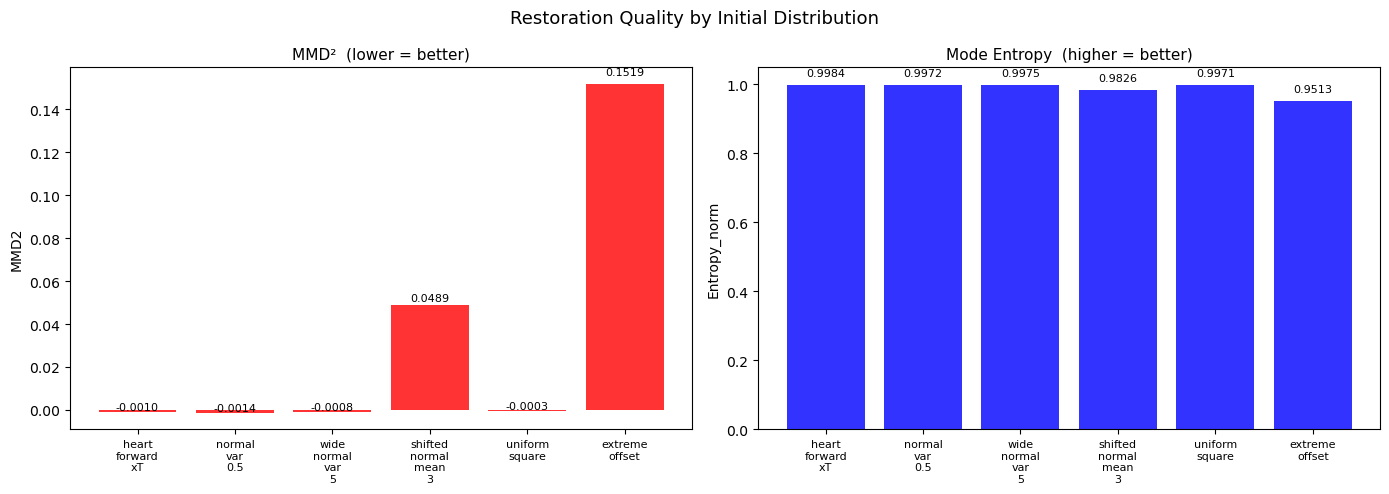

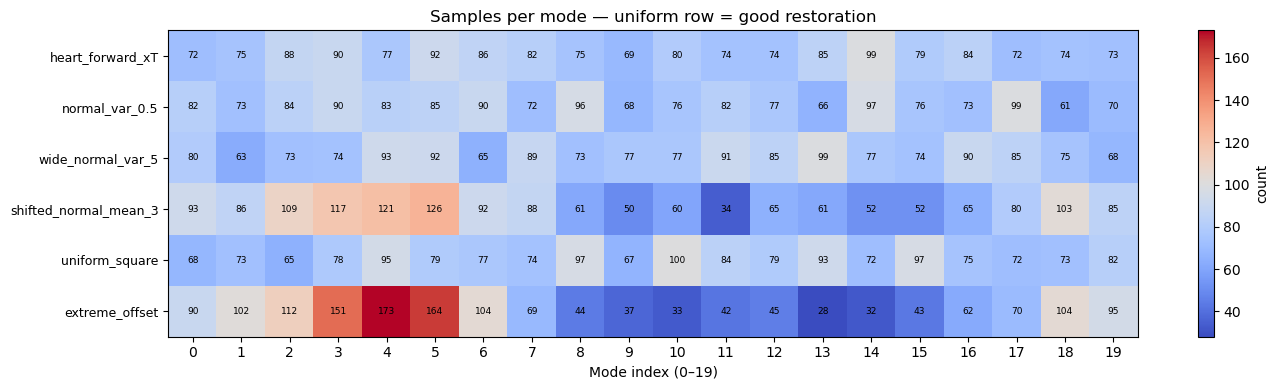

In [68]:
names  = list(results.keys())  # 분포 이름
x_pos  = np.arange(len(names))  # 막대 위치: [0,1,2,...,5]
labels = [n.replace("_", "\n") for n in names]  # _를 줄바꿈으로 변환

fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 가로로 2개 subplot

for ax, metric, title, color in zip(
    axes,
    ["MMD2", "Entropy_norm"],
    ["MMD²  (lower = better)", "Mode Entropy  (higher = better)"],
    ["red", "blue"],
):
    vals = [results[n][metric] for n in names]  # 현재 metric 값
    bars = ax.bar(x_pos, vals, color=color, alpha=0.8) # 막대그래프
    ax.set_xticks(x_pos)  # x축 눈금
    ax.set_xticklabels(labels, fontsize=8) # x축 레이블 이름
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(metric)  # y축 값

    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, # 막대 중앙
                bar.get_height() * 1.02, # 막대 꼭대기 * 1.02 높이
                f"{v:.4f}", ha="center", va="bottom", fontsize=8)

fig.suptitle("Restoration Quality by Initial Distribution", fontsize=13)
plt.tight_layout()
plt.show()

# ── 히트맵 ────────────────────────────────────────────────────
count_matrix = np.stack([results[n]["_counts"] for n in names], axis=0)

plt.figure(figsize=(14,4))
im = plt.imshow(count_matrix, aspect="auto", cmap="coolwarm")
plt.xticks(range(len(heart_means)))  # x축 눈금
plt.xlabel("Mode index (0–19)")
plt.yticks(range(len(names)), names, fontsize=9)  # y축 눈금
plt.title("Samples per mode — uniform row = good restoration")

# 히트맵의 모든 셀 (i,j) 순회하며 중앙에 카운트 숫자 표시
for i in range(len(names)):
    for j in range(len(heart_means)):
        plt.text(j, i, str(count_matrix[i, j]), ha="center", va="center", fontsize=6.5)
plt.colorbar(im, label="count")
plt.tight_layout()
plt.show()